In [ ]:
# Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler


In [ ]:
df = pd.read_csv('/content/smart_home_energy_consumption_large.csv')
df.head()


,Home ID,Appliance Type,Energy Consumption (kWh),Time,Date,Outdoor Temperature (°C),Season,Household Size
0,94,Fridge,0.20,21:12,2023-12-02,-1.0,Fall,2
1,435,Oven,0.23,20:11,2023-08-06,31.1,Summer,5
2,466,Dishwasher,0.32,06:39,2023-11-21,21.3,Fall,3
3,496,Heater,3.92,21:56,2023-01-21,-4.2,Winter,1
4,137,Microwave,0.44,04:31,2023-08-26,34.5,Summer,5


In [ ]:
df.shape


(100000, 8)

In [ ]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 8 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   Home ID                   100000 non-null  int64  
 1   Appliance Type            100000 non-null  object 
 2   Energy Consumption (kWh)  100000 non-null  float64
 3   Time                      100000 non-null  object 
 4   Date                      100000 non-null  object 
 5   Outdoor Temperature (°C)  100000 non-null  float64
 6   Season                    100000 non-null  object 
 7   Household Size            100000 non-null  int64  
dtypes: float64(2), int64(2), object(4)
memory usage: 6.1+ MB


In [ ]:
# MissingValuesCheck
df.isnull().sum()


,0
Home ID,0
Appliance Type,0
Energy Consumption (kWh),0
Time,0
Date,0
Outdoor Temperature (°C),0
Season,0
Household Size,0


In [ ]:
df.describe()


,Home ID,Energy Consumption (kWh),Outdoor Temperature (°C),Household Size
count,100000.000000,100000.000000,100000.000000,100000.000000
mean,250.374980,1.499952,14.950135,3.001770
std,144.435367,1.181176,14.438755,1.417077
min,1.000000,0.100000,-10.000000,1.000000
25%,125.000000,0.590000,2.400000,2.000000
50%,250.000000,1.230000,14.900000,3.000000
75%,375.000000,1.870000,27.400000,4.000000
max,500.000000,5.000000,40.000000,5.000000


In [ ]:
df['Appliance Type'].nunique()


10

In [ ]:
df['Appliance Type'].unique()


array(['Fridge', 'Oven', 'Dishwasher', 'Heater', 'Microwave',
       'Air Conditioning', 'Computer', 'TV', 'Washing Machine', 'Lights'],
      dtype=object)

In [ ]:
# TimestampCreation
df['timestamp'] = pd.to_datetime(
    df['Date'].astype(str) + ' ' + df['Time'].astype(str),
    errors='coerce'
)



In [ ]:
df[['Date','Time','timestamp']].head()



,Date,Time,timestamp
0,2023-12-02,21:12,2023-12-02 21:12:00
1,2023-08-06,20:11,2023-08-06 20:11:00
2,2023-11-21,06:39,2023-11-21 06:39:00
3,2023-01-21,21:56,2023-01-21 21:56:00
4,2023-08-26,04:31,2023-08-26 04:31:00


In [ ]:
df = df.set_index('timestamp')


In [ ]:
df.isnull().sum()


,0
Home ID,0
Appliance Type,0
Energy Consumption (kWh),0
Time,0
Date,0
Outdoor Temperature (°C),0
Season,0
Household Size,0


In [ ]:
# MissingValueHandling
df = df.fillna(method='ffill')


/tmp/ipython-input-4172352942.py:2: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df = df.fillna(method='ffill')


In [ ]:
# OutlierRemoval
upper_limit = df['Energy Consumption (kWh)'].quantile(0.99)
df = df[df['Energy Consumption (kWh)'] <= upper_limit]


In [ ]:
# HourlyResampling
hourly_df = (
    df.groupby('Appliance Type')
      .resample('H')['Energy Consumption (kWh)']
      .sum()
      .reset_index()
)

hourly_df.head()


/tmp/ipython-input-3984419729.py:4: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  .resample('H')['Energy Consumption (kWh)']


,Appliance Type,timestamp,Energy Consumption (kWh)
0,Air Conditioning,2023-01-01 00:00:00,4.42
1,Air Conditioning,2023-01-01 01:00:00,7.61
2,Air Conditioning,2023-01-01 02:00:00,14.80
3,Air Conditioning,2023-01-01 03:00:00,4.19
4,Air Conditioning,2023-01-01 04:00:00,10.68


In [ ]:
# DailyResampling
daily_df = (
    df.groupby('Appliance Type')
      .resample('D')['Energy Consumption (kWh)']
      .sum()
      .reset_index()
)

daily_df.head()


,Appliance Type,timestamp,Energy Consumption (kWh)
0,Air Conditioning,2023-01-01,103.32
1,Air Conditioning,2023-01-02,97.08
2,Air Conditioning,2023-01-03,70.14
3,Air Conditioning,2023-01-04,96.76
4,Air Conditioning,2023-01-05,139.96


In [ ]:
scaler = MinMaxScaler()
hourly_df['Energy_scaled'] = scaler.fit_transform(
    hourly_df[['Energy Consumption (kWh)']]
)


In [ ]:
# TrainValidationTestSplit
from sklearn.model_selection import train_test_split

X = hourly_df[['Energy_scaled']]
y = hourly_df['Energy_scaled']

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, shuffle=False
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, shuffle=False
)


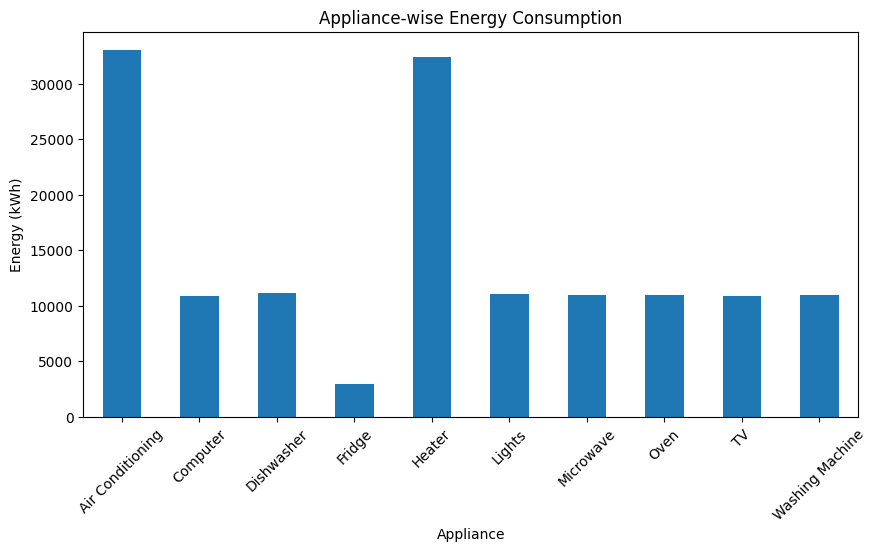

In [ ]:
# Visualization
plt.figure(figsize=(10,5))
hourly_df.groupby('Appliance Type')['Energy Consumption (kWh)'].sum().plot(kind='bar')
plt.title('Appliance-wise Energy Consumption')
plt.ylabel('Energy (kWh)')
plt.xlabel('Appliance')
plt.xticks(rotation=45)
plt.show()


In [ ]:
hourly_df.to_csv('processed_hourly_energy.csv', index=False)
daily_df.to_csv('processed_daily_energy.csv', index=False)
